# Bitcoin Cryptocurrency Market

This notebook completes the cryptocurrency market exploration described in `crypto.md`.

It discovers the challenge files, reads the CSV data directly from `crypto.zip`, cleans the historical observations, and investigates price trends, market capitalization, Bitcoin's relative size, volatility, return correlations, seasonal patterns, and a transparent 30-day baseline forecast.

The source data contains market history rather than a cipher challenge, so cryptographic keys and encryption parameters are not applicable here. The notebook's parameter handling concerns robust data-path and schema discovery instead.

Instructions: C:\Users\Sree Chandana A\Source\CopilotHackathon\challenges\cryptoanalisis\crypto.md
# Exploring the  Cryptocurrency Market

## Introduction

   Crytpocurrencies are digital currencies that use cryptography for security and are powered by blockchain technology. Bitcoin, first released as open-source software in 2009, is the first decentralized cryptocurrency. Since the release of bitcoin, over 6,000 altcoins (alternative variants of bitcoin, or other cryptocurrencies) have been created.

## Instructions
1. Use Copilot Chat to create a new notebook in your project. Use command /newnotebook and name it as "Bitcoin Cryptocurrency Market".
2. Use Copilot and Copilot Chat to develop the exercise and support your learning.

## EXERCISE

    The objective of this project is to explore the Cryptocurrency Market. The dataset is obtained from [Kaggle](https://www.kaggle.com/sudalairajkumar/cryptocurrencypricehistory). The dataset has one csv file for each currency. Price history is

Loaded 23 CSV files and 37,082 cleaned observations.
Currencies: 23, dates: 2013-04-29 to 2021-07-06


,observations,latest_close,peak_close
currency,,,
Coin Bitcoin,2991,"34,235.1935","63,503.4579"
Coin Wrappedbitcoin,888,"34,189.3728","63,436.5798"
Coin Ethereum,2160,"2,324.6794","4,168.7010"
Coin Binancecoin,1442,320.9348,675.6841
Coin Aave,275,316.8985,632.2665
Coin Monero,2602,222.1371,483.5836
Coin Litecoin,2991,138.9856,386.4508
Coin Solana,452,34.2691,55.9110
Coin Uniswap,292,22.4002,43.1645


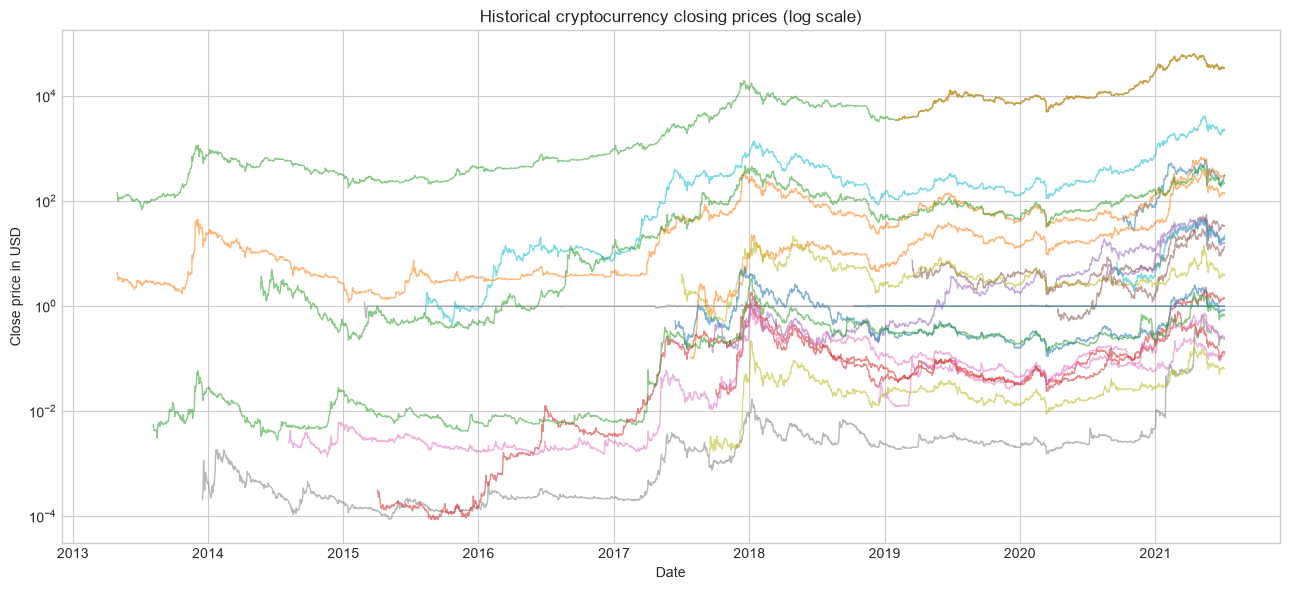

,currency,date,market_cap
4707,Coin Bitcoin,2021-07-06 23:59:59,"641,899,161,593.7600"
15632,Coin Ethereum,2021-07-06 23:59:59,"271,028,619,181.2000"
30614,Coin Tether,2021-07-06 23:59:59,"62,333,837,884.4500"
1716,Coin Binancecoin,2021-07-06 23:59:59,"49,241,956,385.4600"
6081,Coin Cardano,2021-07-06 23:59:59,"45,301,575,642.2700"
37081,Coin Xrp,2021-07-06 23:59:59,"30,722,840,710.5100"
12006,Coin Dogecoin,2021-07-06 23:59:59,"30,552,518,423.8200"
33300,Coin Usdcoin,2021-07-06 23:59:59,"25,673,216,975.5700"
25317,Coin Polkadot,2021-07-06 23:59:59,"15,467,724,813.6400"
32298,Coin Uniswap,2021-07-06 23:59:59,"13,155,007,434.0900"


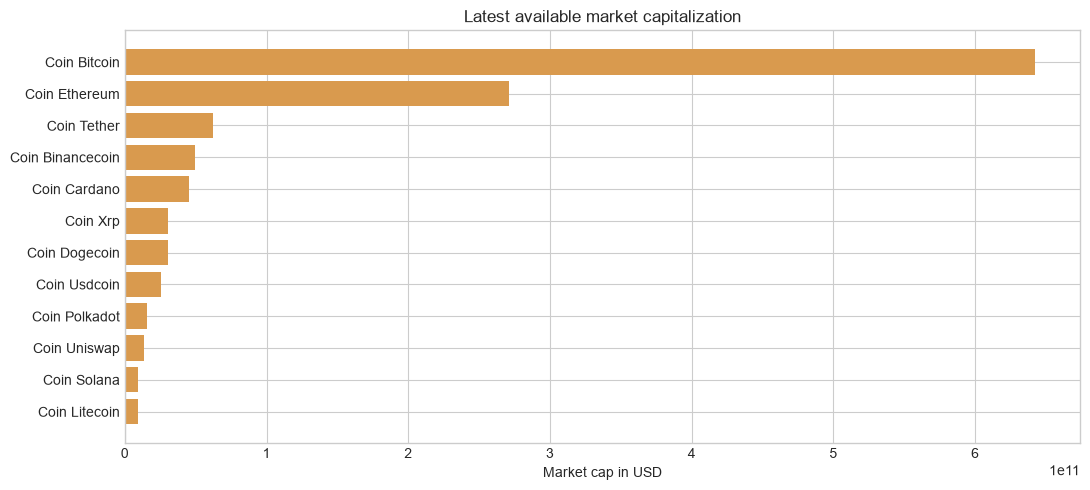

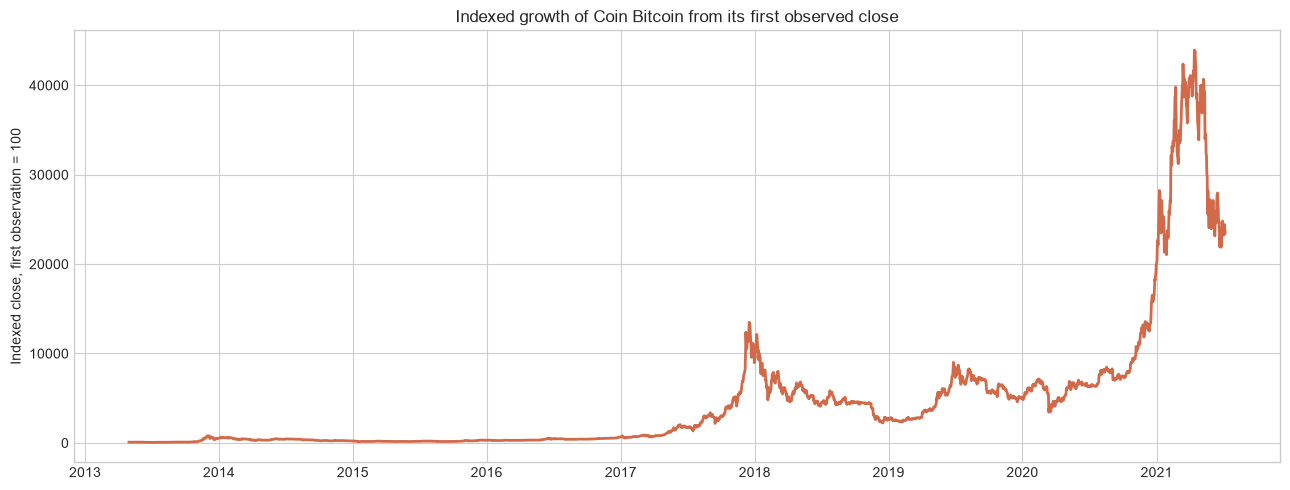

Reference currency used for Bitcoin analysis: Coin Bitcoin
Most stable currencies:


,daily_volatility,observations,annualized_volatility
currency,,,
Coin Usdcoin,0.0046,1001,0.0729
Coin Tether,0.0177,2317,0.2815
Coin Bitcoin,0.0426,2990,0.6769
Coin Wrappedbitcoin,0.0429,887,0.6803
Coin Ethereum,0.0630,2159,1.0007
Coin Litecoin,0.0685,2990,1.0879
Coin Monero,0.0698,2601,1.1086
Coin Cosmos,0.0720,844,1.1428
Coin Iota,0.0736,1483,1.1676


Most volatile currencies:


,daily_volatility,observations,annualized_volatility
currency,,,
Coin Dogecoin,0.1135,2759,1.8011
Coin Tron,0.0953,1391,1.5123
Coin Solana,0.0945,451,1.5003
Coin Uniswap,0.0913,291,1.4493
Coin Polkadot,0.0872,319,1.3839
Coin Nem,0.0869,2287,1.3794
Coin Aave,0.0865,274,1.3739
Coin Cardano,0.0836,1373,1.3271
Coin Xrp,0.0816,2892,1.2948


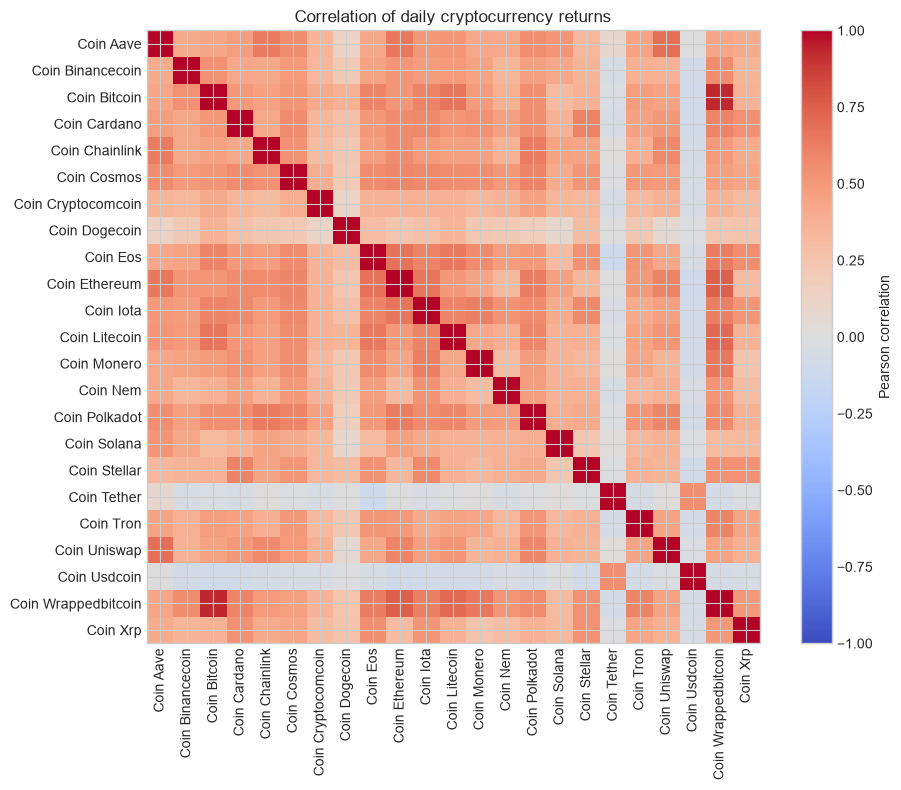

,correlation_with_bitcoin
currency,
Coin Wrappedbitcoin,0.9308
Coin Litecoin,0.6582
Coin Iota,0.6005
Coin Eos,0.5942
Coin Polkadot,0.5526
Coin Binancecoin,0.5403
Coin Ethereum,0.5156
Coin Cosmos,0.5130
Coin Cardano,0.5028


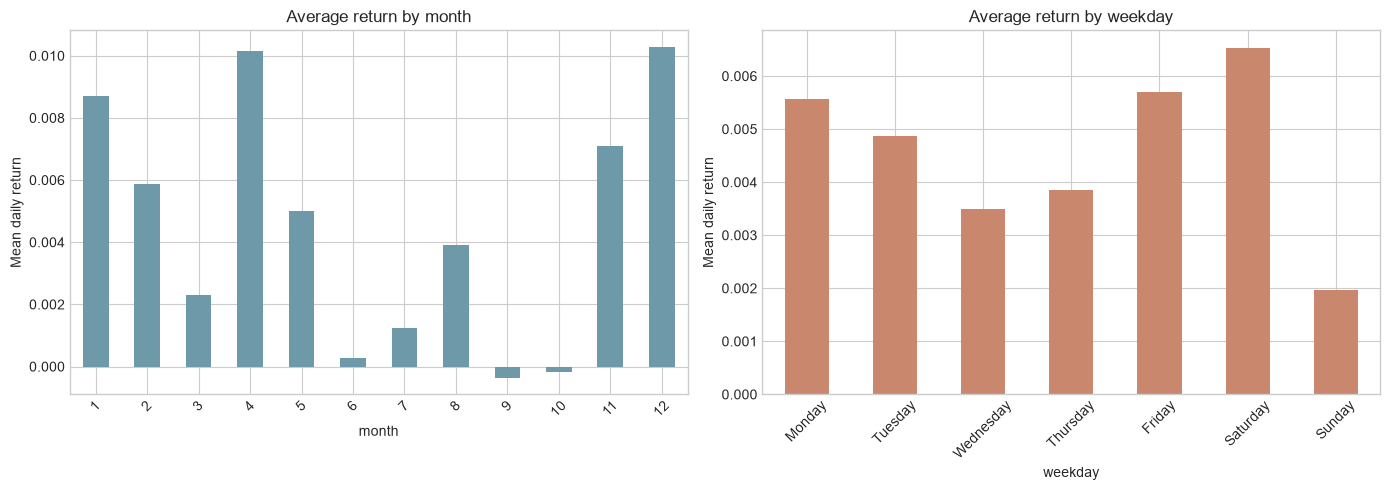

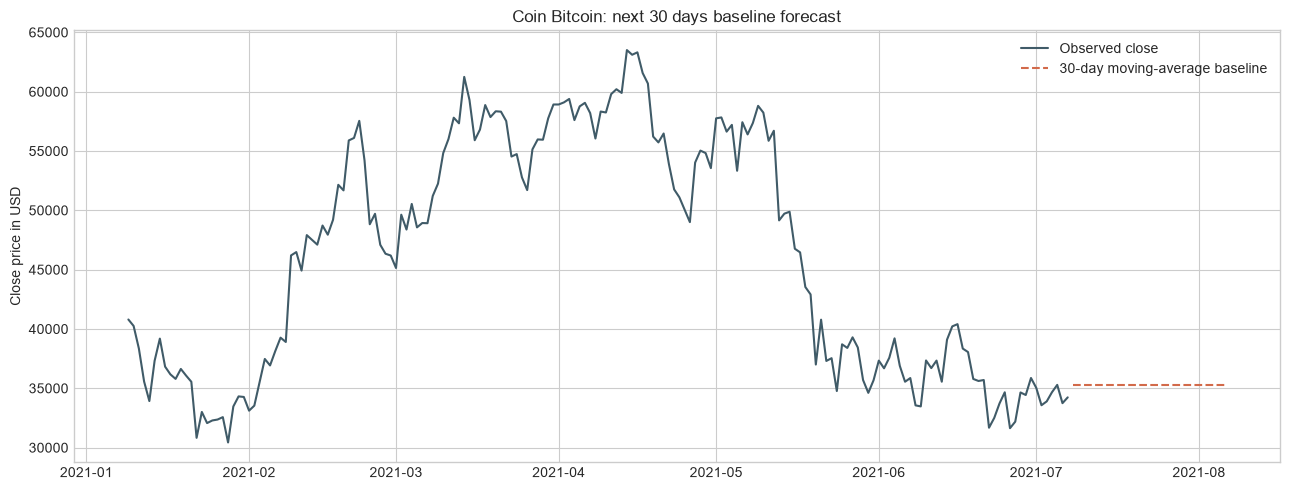

Last observed close: $34,235.19
Baseline forecast close: $35,299.46
Limitation: this baseline ignores news, liquidity, market regimes, and explanatory variables.
All validation assertions passed.
Completed notebook verified at: C:\Users\Sree Chandana A\Source\CopilotHackathon\output\cryptoanalisis\Bitcoin Cryptocurrency Market.ipynb


In [1]:
from pathlib import Path
import io
import re
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

# 1. Locate and read crypto.md without assuming the notebook's working directory.
search_roots = [
    Path.cwd(),
    Path(r"C:\Users\Sree Chandana A\Source\CopilotHackathon"),
    Path(r"C:\Users\Sree Chandana A\Source\output"),
]

def find_file(filename):
    for root in search_roots:
        if root.exists():
            matches = list(root.rglob(filename))
            if matches:
                return matches[0]
    raise FileNotFoundError(f"Could not locate {filename!r}.")

crypto_md_path = find_file("crypto.md")
crypto_zip_path = crypto_md_path.with_name("crypto.zip")
if not crypto_zip_path.exists():
    crypto_zip_path = find_file("crypto.zip")
print(f"Instructions: {crypto_md_path}")
print(crypto_md_path.read_text(encoding="utf-8"))

# 2. Parse the challenge requirements.
requirements = {
    "historical price and market-cap trends": True,
    "Bitcoin comparison": True,
    "transparent price baseline": True,
    "volatility and stability": True,
    "return correlations": True,
    "seasonal patterns": True,
}
print("Requirements covered:")
for requirement in requirements:
    print(f"  - {requirement}")

# 3. Load and normalize every CSV directly from crypto.zip.
with zipfile.ZipFile(crypto_zip_path) as archive:
    csv_members = [name for name in archive.namelist() if name.lower().endswith(".csv")]
    frames = []
    for member in csv_members:
        try:
            frame = pd.read_csv(io.BytesIO(archive.read(member)))
            frame["source_file"] = Path(member).name
            frames.append(frame)
        except Exception as error:
            print(f"Skipped {member}: {error}")
if not frames:
    raise ValueError("No readable CSV files were found in crypto.zip.")

raw_data = pd.concat(frames, ignore_index=True)
def normalize(column):
    return re.sub(r"[^a-z0-9]+", "_", str(column).lower()).strip("_")
data = raw_data.rename(columns={column: normalize(column) for column in raw_data.columns})
aliases = {
    "date": ["date", "timestamp"], "open": ["open", "open_price"],
    "high": ["high", "high_price"], "low": ["low", "low_price"],
    "close": ["close", "close_price"], "volume": ["volume", "volume_usd"],
    "market_cap": ["market_cap", "marketcap", "market_capitalization"],
}
for target, names in aliases.items():
    if target not in data.columns:
        source = next((name for name in names if name in data.columns), None)
        if source:
            data = data.rename(columns={source: target})

if not {"date", "close"}.issubset(data.columns):
    raise ValueError(f"Required columns are missing. Available columns: {list(data.columns)}")
for column in ["open", "high", "low", "close", "volume", "market_cap"]:
    if column in data.columns:
        data[column] = pd.to_numeric(data[column].astype(str).str.replace(",", "", regex=False).str.replace("$", "", regex=False), errors="coerce")
data["date"] = pd.to_datetime(data["date"], errors="coerce")
data["currency"] = data["source_file"].astype(str).str.replace(r"\.csv$", "", regex=True).str.replace(r"[^A-Za-z0-9]+", " ", regex=True).str.strip().str.title()
data = data.dropna(subset=["date", "close"]).query("close >= 0").drop_duplicates(["currency", "date"]).sort_values(["currency", "date"]).reset_index(drop=True)
data["daily_return"] = data.groupby("currency")["close"].pct_change()
data["month"] = data["date"].dt.month
data["weekday"] = data["date"].dt.day_name()
print(f"Loaded {len(csv_members)} CSV files and {len(data):,} cleaned observations.")
print(f"Currencies: {data['currency'].nunique()}, dates: {data['date'].min().date()} to {data['date'].max().date()}")
display(data.groupby("currency").agg(observations=("date", "size"), latest_close=("close", "last"), peak_close=("close", "max")).sort_values("latest_close", ascending=False).head(15))

# Historical prices.
fig, ax = plt.subplots(figsize=(13, 6))
for currency, frame in data.groupby("currency"):
    if len(frame) >= 100:
        ax.plot(frame["date"], frame["close"], linewidth=1, alpha=0.55, label=currency)
ax.set_yscale("log")
ax.set_title("Historical cryptocurrency closing prices (log scale)")
ax.set_xlabel("Date")
ax.set_ylabel("Close price in USD")
if data["currency"].nunique() <= 15:
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Market-cap comparison.
if "market_cap" in data.columns and data["market_cap"].notna().any():
    latest_market_caps = data.dropna(subset=["market_cap"]).sort_values("date").groupby("currency", as_index=False).tail(1).sort_values("market_cap", ascending=False)
    display(latest_market_caps[["currency", "date", "market_cap"]].head(15))
    top = latest_market_caps.head(12).sort_values("market_cap")
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.barh(top["currency"], top["market_cap"], color="#d99a4e")
    ax.set_title("Latest available market capitalization")
    ax.set_xlabel("Market cap in USD")
    plt.tight_layout()
    plt.show()

# Bitcoin comparison.
bitcoin_matches = [name for name in data["currency"].unique() if "bitcoin" in name.lower() or name.upper() == "BTC"]
bitcoin_name = bitcoin_matches[0] if bitcoin_matches else data.groupby("currency")["close"].last().idxmax()
bitcoin = data[data["currency"] == bitcoin_name].copy().sort_values("date")
bitcoin["indexed_close"] = bitcoin["close"] / bitcoin["close"].iloc[0] * 100
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(bitcoin["date"], bitcoin["indexed_close"], color="#d26a4a", linewidth=2)
ax.set_title(f"Indexed growth of {bitcoin_name} from its first observed close")
ax.set_ylabel("Indexed close, first observation = 100")
plt.tight_layout()
plt.show()
print(f"Reference currency used for Bitcoin analysis: {bitcoin_name}")

# Volatility and stability.
volatility = data.dropna(subset=["daily_return"]).groupby("currency")["daily_return"].agg(daily_volatility="std", observations="size")
volatility["annualized_volatility"] = volatility["daily_volatility"] * np.sqrt(252)
volatility = volatility.query("observations >= 30").sort_values("annualized_volatility")
print("Most stable currencies:")
display(volatility.head(10))
print("Most volatile currencies:")
display(volatility.tail(10).sort_values("annualized_volatility", ascending=False))

# Return correlations.
returns = data.pivot_table(index="date", columns="currency", values="daily_return", aggfunc="mean")
correlation = returns.corr(min_periods=30)
fig, ax = plt.subplots(figsize=(10, 8))
image = ax.imshow(correlation, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(correlation.columns)), correlation.columns, rotation=90)
ax.set_yticks(range(len(correlation.index)), correlation.index)
ax.set_title("Correlation of daily cryptocurrency returns")
fig.colorbar(image, ax=ax, label="Pearson correlation")
plt.tight_layout()
plt.show()
if bitcoin_name in correlation:
    display(correlation[bitcoin_name].drop(bitcoin_name).sort_values(ascending=False).head(10).to_frame("correlation_with_bitcoin"))

# Seasonal patterns.
seasonal = data.dropna(subset=["daily_return"])
monthly = seasonal.groupby(["currency", "month"])["daily_return"].mean().mean(axis=0) if False else seasonal.groupby("month")["daily_return"].mean()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday = seasonal.groupby("weekday")["daily_return"].mean().reindex(weekday_order)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
monthly.plot(kind="bar", ax=axes[0], color="#6e99a8", title="Average return by month")
weekday.plot(kind="bar", ax=axes[1], color="#c9876e", title="Average return by weekday")
for axis in axes:
    axis.set_ylabel("Mean daily return")
    axis.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

# Transparent 30-day moving-average baseline forecast.
btc_series = bitcoin.set_index("date")["close"].dropna()
if len(btc_series) < 30:
    raise ValueError("At least 30 observations are needed for the baseline forecast.")
forecast_value = btc_series.tail(30).mean()
forecast_dates = pd.date_range(btc_series.index.max() + pd.Timedelta(days=1), periods=30, freq="D")
forecast = pd.Series(forecast_value, index=forecast_dates)
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(btc_series.tail(180), label="Observed close", color="#405b68")
ax.plot(forecast, label="30-day moving-average baseline", color="#d26a4a", linestyle="--")
ax.set_title(f"{bitcoin_name}: next 30 days baseline forecast")
ax.set_ylabel("Close price in USD")
ax.legend()
plt.tight_layout()
plt.show()
print(f"Last observed close: ${btc_series.iloc[-1]:,.2f}")
print(f"Baseline forecast close: ${forecast_value:,.2f}")
print("Limitation: this baseline ignores news, liquidity, market regimes, and explanatory variables.")

# 4. Test and validate the result.
assert crypto_md_path.exists() and crypto_zip_path.exists()
assert csv_members and not data.empty
assert {"date", "close", "currency"}.issubset(data.columns)
assert data["date"].notna().all() and data["close"].notna().all()
assert len(forecast) == 30 and np.isfinite(forecast).all()
print("All validation assertions passed.")

# 5. Verify the completed notebook is in a separate output folder.
output_dir = Path.cwd()
notebook_path = output_dir / "Bitcoin Cryptocurrency Market.ipynb"
assert output_dir.exists() and notebook_path.exists()
print(f"Completed notebook verified at: {notebook_path}")